In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset loaded successfully.")
print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully.
Number of rows   : 23486
Number of columns: 11


,number,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [2]:
def initial_data_audit(data):

    audit_summary = pd.DataFrame({
        "Column": data.columns,
        "Data Type": data.dtypes.astype(str).values,
        "Non-Null Count": data.notna().sum().values,
        "Missing Count": data.isna().sum().values,
        "Missing Percentage": (
            data.isna().mean().mul(100).round(2).values
        ),
        "Unique Values": data.nunique(dropna=True).values
    })

    print("Dataset Shape:", data.shape)
    print("Duplicate Rows:", data.duplicated().sum())

    return audit_summary

audit_report = initial_data_audit(df)
display(audit_report)

Dataset Shape: (23486, 11)
Duplicate Rows: 0


,Column,Data Type,Non-Null Count,Missing Count,Missing Percentage,Unique Values
0,number,int64,23486,0,0.00,23486
1,Clothing ID,int64,23486,0,0.00,1206
2,Age,int64,23486,0,0.00,77
3,Title,str,19676,3810,16.22,13993
4,Review Text,str,22641,845,3.60,22634
5,Rating,int64,23486,0,0.00,5
6,Recommended IND,int64,23486,0,0.00,2
7,Positive Feedback Count,int64,23486,0,0.00,82
8,Division Name,str,23472,14,0.06,3
9,Department Name,str,23472,14,0.06,6


In [3]:
index_columns = [
    "number"
]

identifier_columns = [
    "Clothing ID"
]

numerical_columns = [
    "Age",
    "Rating",
    "Positive Feedback Count"
]

binary_columns = [
    "Recommended IND"
]

categorical_columns = [
    "Division Name",
    "Department Name",
    "Class Name"
]

text_columns = [
    "Title",
    "Review Text"
]

column_roles = {
    "Index Columns": index_columns,
    "Identifier Columns": identifier_columns,
    "Numerical Columns": numerical_columns,
    "Binary Columns": binary_columns,
    "Categorical Columns": categorical_columns,
    "Text Columns": text_columns
}

for role, columns in column_roles.items():
    print(f"{role}: {columns}")

Index Columns: ['number']
Identifier Columns: ['Clothing ID']
Numerical Columns: ['Age', 'Rating', 'Positive Feedback Count']
Binary Columns: ['Recommended IND']
Categorical Columns: ['Division Name', 'Department Name', 'Class Name']
Text Columns: ['Title', 'Review Text']


In [4]:
def validate_column_roles(data, role_dictionary):

    assigned_columns = []

    for columns in role_dictionary.values():
        assigned_columns.extend(columns)

    missing_in_dataset = [
        column for column in assigned_columns
        if column not in data.columns
    ]

    unassigned_columns = [
        column for column in data.columns
        if column not in assigned_columns
    ]

    duplicate_assignments = sorted({
        column
        for column in assigned_columns
        if assigned_columns.count(column) > 1
    })

    print("Columns missing from dataset:", missing_in_dataset)
    print("Unassigned dataset columns:", unassigned_columns)
    print("Columns assigned multiple roles:", duplicate_assignments)

    if (
        not missing_in_dataset
        and not unassigned_columns
        and not duplicate_assignments
    ):
        print("\nValidation successful: all columns have correct roles.")

validate_column_roles(df, column_roles)

Columns missing from dataset: []
Unassigned dataset columns: []
Columns assigned multiple roles: []

Validation successful: all columns have correct roles.


In [5]:
print("Numerical columns preview:")
display(df[numerical_columns].head())

print("\nBinary column value counts:")
print(df["Recommended IND"].value_counts(dropna=False))

print("\nCategorical columns preview:")
display(df[categorical_columns].head())

print("\nText columns preview:")
display(df[text_columns].head())

Numerical columns preview:


,Age,Rating,Positive Feedback Count
0,33,4,0
1,34,5,4
2,60,3,0
3,50,5,0
4,47,5,6



Binary column value counts:
Recommended IND
1    19314
0     4172
Name: count, dtype: int64

Categorical columns preview:


,Division Name,Department Name,Class Name
0,Initmates,Intimate,Intimates
1,General,Dresses,Dresses
2,General,Dresses,Dresses
3,General Petite,Bottoms,Pants
4,General,Tops,Blouses



Text columns preview:


,Title,Review Text
0,NaN,Absolutely wonderful - silky and sexy and comf...
1,NaN,Love this dress! it's sooo pretty. i happene...
2,Some major design flaws,I had such high hopes for this dress and reall...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl..."
4,Flattering shirt,This shirt is very flattering to all due to th...


In [6]:
df_raw = df.copy()

print("Original dataset backup created.")
print("Original shape:", df_raw.shape)

Original dataset backup created.
Original shape: (23486, 11)


In [7]:
df_clean = df.copy()

df_clean = (
    df_clean
    .rename(columns={"number": "Record ID"})
    .set_index("Record ID")
)

print("Clean dataset shape:", df_clean.shape)
print("Index name:", df_clean.index.name)

display(df_clean.head())

Clean dataset shape: (23486, 10)
Index name: Record ID


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
Record ID,,,,,,,,,,
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [8]:
columns_to_strip = (
    text_columns +
    categorical_columns
)

for column in columns_to_strip:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
    )

    df_clean[column] = df_clean[column].replace("", pd.NA)

print("Text and categorical formatting cleaned.")

Text and categorical formatting cleaned.


In [9]:
for column in numerical_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

for column in binary_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    ).astype("Int64")

print(df_clean[numerical_columns + binary_columns].dtypes)

Age                        int64
Rating                     int64
Positive Feedback Count    int64
Recommended IND            Int64
dtype: object


In [10]:
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna("Unknown")

print("Missing categorical values after cleaning:")
print(df_clean[categorical_columns].isna().sum())

Missing categorical values after cleaning:
Division Name      0
Department Name    0
Class Name         0
dtype: int64


In [11]:
def generate_text_coverage(data, columns):

    records = []

    for column in columns:
        available = data[column].notna().sum()
        missing = data[column].isna().sum()
        total = len(data)

        records.append({
            "Column": column,
            "Available Records": available,
            "Missing Records": missing,
            "Coverage (%)": round(
                available / total * 100,
                2
            )
        })

    return pd.DataFrame(records)

text_coverage_report = generate_text_coverage(
    df_clean,
    text_columns
)

display(text_coverage_report)

,Column,Available Records,Missing Records,Coverage (%)
0,Title,19676,3810,83.78
1,Review Text,22641,845,96.40


In [12]:
possible_duplicates = df_clean.duplicated(
    keep=False
)

possible_duplicate_count = df_clean.duplicated().sum()

print(
    "Possible duplicates without Record ID:",
    possible_duplicate_count
)

display(
    df_clean.loc[possible_duplicates].head(10)
)

Possible duplicates without Record ID: 21


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
Record ID,,,,,,,,,,
298,1104,39,<NA>,<NA>,5,1,0,General,Dresses,Dresses
493,1104,39,<NA>,<NA>,5,1,0,General,Dresses,Dresses
1004,1094,30,<NA>,<NA>,5,1,0,General,Dresses,Dresses
2739,1094,36,<NA>,<NA>,5,1,0,General Petite,Dresses,Dresses
2941,829,66,<NA>,<NA>,5,1,0,General Petite,Tops,Blouses
2959,1094,30,<NA>,<NA>,5,1,0,General,Dresses,Dresses
3961,895,36,<NA>,<NA>,5,1,0,General Petite,Tops,Fine gauge
3976,1078,35,<NA>,<NA>,5,1,0,General,Dresses,Dresses
4850,829,66,<NA>,<NA>,5,1,0,General Petite,Tops,Blouses


In [13]:
cleaning_summary = pd.DataFrame({
    "Data Type": df_clean.dtypes.astype(str),
    "Missing Count": df_clean.isna().sum(),
    "Unique Values": df_clean.nunique(dropna=True)
})

print("Final cleaned shape:", df_clean.shape)
display(cleaning_summary)

Final cleaned shape: (23486, 10)


,Data Type,Missing Count,Unique Values
Clothing ID,int64,0,1206
Age,int64,0,77
Title,string,3810,13993
Review Text,string,845,22634
Rating,int64,0,5
Recommended IND,Int64,0,2
Positive Feedback Count,int64,0,82
Division Name,string,0,4
Department Name,string,0,7
Class Name,string,0,21


In [14]:
def generate_numerical_summary(data, columns):

    summary_records = []

    for column in columns:

        if column not in data.columns:
            print(f"Warning: '{column}' column not found.")
            continue

        series = pd.to_numeric(
            data[column],
            errors="coerce"
        )

        valid_series = series.dropna()

        if valid_series.empty:
            print(f"Warning: '{column}' has no valid values.")
            continue

        q1 = valid_series.quantile(0.25)
        q3 = valid_series.quantile(0.75)

        mode_values = valid_series.mode()

        if len(mode_values) > 0:
            mode_result = ", ".join(
                mode_values.astype(str).tolist()
            )
        else:
            mode_result = "No mode"

        summary_records.append({
            "Column": column,
            "Count": valid_series.count(),
            "Missing": series.isna().sum(),
            "Mean": valid_series.mean(),
            "Median": valid_series.median(),
            "Mode": mode_result,
            "Variance": valid_series.var(),
            "Standard Deviation": valid_series.std(),
            "Minimum": valid_series.min(),
            "Q1": q1,
            "Q3": q3,
            "Maximum": valid_series.max(),
            "Range": (
                valid_series.max() -
                valid_series.min()
            ),
            "IQR": q3 - q1,
            "Skewness": valid_series.skew(),
            "Kurtosis": valid_series.kurt()
        })

    summary_df = pd.DataFrame(summary_records)

    numerical_result_columns = summary_df.select_dtypes(
        include="number"
    ).columns

    summary_df[numerical_result_columns] = (
        summary_df[numerical_result_columns].round(3)
    )

    return summary_df

In [15]:
numerical_summary = generate_numerical_summary(
    df_clean,
    numerical_columns
)

display(numerical_summary)

,Column,Count,Missing,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Q1,Q3,Maximum,Range,IQR,Skewness,Kurtosis
0,Age,23486,0,43.199,41.0,39,150.787,12.280,18,34.0,52.0,99,81,18.0,0.526,-0.112
1,Rating,23486,0,4.196,5.0,5,1.232,1.110,1,4.0,5.0,5,4,1.0,-1.314,0.804
2,Positive Feedback Count,23486,0,2.536,1.0,0,32.515,5.702,0,0.0,3.0,122,122,3.0,6.473,71.693


In [17]:
def display_numerical_summaries(summary):

    for _, row in summary.iterrows():

        column_name = row["Column"]

        print("=" * 55)
        print(f"STATISTICAL SUMMARY: {column_name}")
        print("=" * 55)

        column_result = row.drop(
            labels="Column"
        ).to_frame(name="Value")

        display(column_result)

display_numerical_summaries(numerical_summary)

STATISTICAL SUMMARY: Age


,Value
Count,23486
Missing,0
Mean,43.199
Median,41.0
Mode,39
Variance,150.787
Standard Deviation,12.28
Minimum,18
Q1,34.0
Q3,52.0


STATISTICAL SUMMARY: Rating


,Value
Count,23486
Missing,0
Mean,4.196
Median,5.0
Mode,5
Variance,1.232
Standard Deviation,1.11
Minimum,1
Q1,4.0
Q3,5.0


STATISTICAL SUMMARY: Positive Feedback Count


,Value
Count,23486
Missing,0
Mean,2.536
Median,1.0
Mode,0
Variance,32.515
Standard Deviation,5.702
Minimum,0
Q1,0.0
Q3,3.0


In [18]:
def interpret_skewness(skewness):

    absolute_skewness = abs(skewness)

    if absolute_skewness < 0.50:
        shape = "approximately symmetric"

    elif absolute_skewness < 1.00:
        shape = "moderately skewed"

    else:
        shape = "strongly skewed"

    if skewness > 0.10:
        direction = "to the right"
    elif skewness < -0.10:
        direction = "to the left"
    else:
        direction = ""

    if direction:
        return f"{shape} {direction}"

    return shape

def interpret_kurtosis(kurtosis):

    if kurtosis > 1:
        return (
            "heavy tails, suggesting a greater possibility "
            "of extreme values"
        )

    elif kurtosis < -1:
        return (
            "light tails, suggesting fewer extreme values"
        )

    return (
        "a tail pattern reasonably close to a normal distribution"
    )

def interpret_variability(mean, standard_deviation):

    if mean == 0 or pd.isna(mean):
        return "variability cannot be compared using the mean"

    coefficient_of_variation = (
        standard_deviation / abs(mean)
    ) * 100

    if coefficient_of_variation < 15:
        level = "low"
    elif coefficient_of_variation < 30:
        level = "moderate"
    else:
        level = "high"

    return (
        f"{level} relative variability "
        f"(coefficient of variation: "
        f"{coefficient_of_variation:.1f}%)"
    )

In [19]:
def generate_numerical_insights(summary):

    insights = []

    for _, row in summary.iterrows():

        column = row["Column"]
        mean = row["Mean"]
        median = row["Median"]
        mode = row["Mode"]
        standard_deviation = row["Standard Deviation"]
        minimum = row["Minimum"]
        maximum = row["Maximum"]
        q1 = row["Q1"]
        q3 = row["Q3"]
        skewness = row["Skewness"]
        kurtosis = row["Kurtosis"]
        missing = row["Missing"]

        sentences = []

        sentences.append(
            f"{column} has an average value of {mean:.2f}, "
            f"a median of {median:.2f}, and a mode of {mode}."
        )

        sentences.append(
            f"Values range from {minimum:.2f} to {maximum:.2f}. "
            f"The middle 50% of observations lie between "
            f"{q1:.2f} and {q3:.2f}."
        )

        comparison_threshold = max(
            standard_deviation * 0.10,
            0.01
        )

        if abs(mean - median) <= comparison_threshold:
            sentences.append(
                "The mean and median are relatively close, "
                "indicating a balanced central distribution."
            )

        elif mean > median:
            sentences.append(
                "The mean is greater than the median, suggesting "
                "that some higher values are lifting the average."
            )

        else:
            sentences.append(
                "The mean is lower than the median, suggesting "
                "that some lower values are pulling down the average."
            )

        sentences.append(
            f"The distribution is "
            f"{interpret_skewness(skewness)}."
        )

        sentences.append(
            f"It shows "
            f"{interpret_variability(mean, standard_deviation)}."
        )

        sentences.append(
            f"Its kurtosis indicates "
            f"{interpret_kurtosis(kurtosis)}."
        )

        if missing == 0:
            sentences.append(
                "No missing values were found in this column."
            )
        else:
            sentences.append(
                f"The column contains {int(missing)} missing values."
            )

        insights.append({
            "Column": column,
            "Insight": " ".join(sentences)
        })

    return pd.DataFrame(insights)

In [20]:
def generate_domain_insights(summary):

    domain_insights = []

    summary_lookup = summary.set_index("Column")

    if "Age" in summary_lookup.index:
        age = summary_lookup.loc["Age"]

        domain_insights.append(
            "Customer Age: "
            f"The average reviewer age is {age['Mean']:.1f} years, "
            f"while the median age is {age['Median']:.0f} years. "
            f"Half of the reviewers are approximately between "
            f"{age['Q1']:.0f} and {age['Q3']:.0f} years old."
        )

    if "Rating" in summary_lookup.index:
        rating = summary_lookup.loc["Rating"]

        if rating["Mean"] >= 4:
            sentiment_description = (
                "overall customer satisfaction appears high"
            )
        elif rating["Mean"] >= 3:
            sentiment_description = (
                "customer satisfaction appears mixed or moderate"
            )
        else:
            sentiment_description = (
                "overall customer satisfaction appears low"
            )

        domain_insights.append(
            "Customer Ratings: "
            f"The average product rating is "
            f"{rating['Mean']:.2f} out of 5, and the most common "
            f"rating is {rating['Mode']}. Therefore, "
            f"{sentiment_description}."
        )

    if "Positive Feedback Count" in summary_lookup.index:
        feedback = summary_lookup.loc[
            "Positive Feedback Count"
        ]

        domain_insights.append(
            "Positive Feedback: "
            f"Reviews receive an average of "
            f"{feedback['Mean']:.2f} positive feedback votes, "
            f"while the median is {feedback['Median']:.0f}. "
            "If the mean is considerably above the median, a small "
            "number of highly useful reviews are increasing the "
            "overall average."
        )

    return domain_insights

In [21]:
numerical_insights_df = generate_numerical_insights(
    numerical_summary
)

domain_insights = generate_domain_insights(
    numerical_summary
)

print("=" * 70)
print("AUTOMATED NUMERICAL INSIGHTS")
print("=" * 70)

for _, row in numerical_insights_df.iterrows():
    print(f"\n{row['Column']}")
    print("-" * len(row["Column"]))
    print(row["Insight"])

print("\n" + "=" * 70)
print("FASHION INDUSTRY INSIGHTS")
print("=" * 70)

for insight in domain_insights:
    print(f"\n• {insight}")

AUTOMATED NUMERICAL INSIGHTS

Age
---
Age has an average value of 43.20, a median of 41.00, and a mode of 39. Values range from 18.00 to 99.00. The middle 50% of observations lie between 34.00 and 52.00. The mean is greater than the median, suggesting that some higher values are lifting the average. The distribution is moderately skewed to the right. It shows moderate relative variability (coefficient of variation: 28.4%). Its kurtosis indicates a tail pattern reasonably close to a normal distribution. No missing values were found in this column.

Rating
------
Rating has an average value of 4.20, a median of 5.00, and a mode of 5. Values range from 1.00 to 5.00. The middle 50% of observations lie between 4.00 and 5.00. The mean is lower than the median, suggesting that some lower values are pulling down the average. The distribution is strongly skewed to the left. It shows moderate relative variability (coefficient of variation: 26.5%). Its kurtosis indicates a tail pattern reasonably

In [22]:
categorical_report_data = df_clean.copy()

recommendation_mapping = {
    1: "Recommended",
    0: "Not Recommended"
}

categorical_report_data["Recommendation Status"] = (
    categorical_report_data["Recommended IND"]
    .map(recommendation_mapping)
    .fillna("Unknown")
)

categorical_report_columns = (
    categorical_columns +
    ["Recommendation Status"]
)

display(
    categorical_report_data[
        categorical_report_columns
    ].head()
)

,Division Name,Department Name,Class Name,Recommendation Status
Record ID,,,,
0,Initmates,Intimate,Intimates,Recommended
1,General,Dresses,Dresses,Recommended
2,General,Dresses,Dresses,Not Recommended
3,General Petite,Bottoms,Pants,Recommended
4,General,Tops,Blouses,Recommended


In [23]:
def generate_categorical_summary(data, columns):

    summary_records = []
    frequency_tables = {}

    for column in columns:

        if column not in data.columns:
            print(f"Warning: '{column}' column not found.")
            continue

        series = (
            data[column]
            .astype("string")
            .fillna("Unknown")
        )

        frequency = series.value_counts(dropna=False)

        percentage = (
            series.value_counts(
                normalize=True,
                dropna=False
            ) * 100
        )

        frequency_table = pd.DataFrame({
            "Category": frequency.index,
            "Frequency": frequency.values,
            "Percentage": percentage.values
        })

        frequency_table["Percentage"] = (
            frequency_table["Percentage"].round(2)
        )

        frequency_tables[column] = frequency_table

        top_category = frequency_table.iloc[0]

        summary_records.append({
            "Column": column,
            "Total Records": len(series),
            "Unique Categories": series.nunique(),
            "Most Frequent Category": top_category["Category"],
            "Top Category Frequency": int(
                top_category["Frequency"]
            ),
            "Top Category Percentage": float(
                top_category["Percentage"]
            ),
            "Least Frequent Category": (
                frequency_table.iloc[-1]["Category"]
            ),
            "Least Category Frequency": int(
                frequency_table.iloc[-1]["Frequency"]
            )
        })

    summary_df = pd.DataFrame(summary_records)

    return summary_df, frequency_tables

In [24]:
(
    categorical_summary,
    categorical_frequency_tables
) = generate_categorical_summary(
    categorical_report_data,
    categorical_report_columns
)

display(categorical_summary)

,Column,Total Records,Unique Categories,Most Frequent Category,Top Category Frequency,Top Category Percentage,Least Frequent Category,Least Category Frequency
0,Division Name,23486,4,General,13850,58.97,Unknown,14
1,Department Name,23486,7,Tops,10468,44.57,Unknown,14
2,Class Name,23486,21,Dresses,6319,26.91,Chemises,1
3,Recommendation Status,23486,2,Recommended,19314,82.24,Not Recommended,4172


In [25]:
def display_frequency_tables(frequency_tables):

    for column, table in frequency_tables.items():

        print("=" * 60)
        print(f"FREQUENCY DISTRIBUTION: {column}")
        print("=" * 60)

        display(table)

display_frequency_tables(
    categorical_frequency_tables
)

FREQUENCY DISTRIBUTION: Division Name


,Category,Frequency,Percentage
0,General,13850,58.97
1,General Petite,8120,34.57
2,Initmates,1502,6.4
3,Unknown,14,0.06


FREQUENCY DISTRIBUTION: Department Name


,Category,Frequency,Percentage
0,Tops,10468,44.57
1,Dresses,6319,26.91
2,Bottoms,3799,16.18
3,Intimate,1735,7.39
4,Jackets,1032,4.39
5,Trend,119,0.51
6,Unknown,14,0.06


FREQUENCY DISTRIBUTION: Class Name


,Category,Frequency,Percentage
0,Dresses,6319,26.91
1,Knits,4843,20.62
2,Blouses,3097,13.19
3,Sweaters,1428,6.08
4,Pants,1388,5.91
5,Jeans,1147,4.88
6,Fine gauge,1100,4.68
7,Skirts,945,4.02
8,Jackets,704,3.0
9,Lounge,691,2.94


FREQUENCY DISTRIBUTION: Recommendation Status


,Category,Frequency,Percentage
0,Recommended,19314,82.24
1,Not Recommended,4172,17.76


In [27]:
def interpret_category_concentration(top_percentage):

    if top_percentage >= 50:
        return (
            "This category clearly dominates the distribution."
        )

    elif top_percentage >= 30:
        return (
            "This category has a strong presence, although other "
            "categories also contribute meaningfully."
        )

    else:
        return (
            "The distribution is relatively diverse, with no single "
            "category holding a majority share."
        )

In [28]:
def generate_categorical_insights(summary):

    insights = []

    for _, row in summary.iterrows():

        column = row["Column"]
        unique_count = row["Unique Categories"]
        top_category = row["Most Frequent Category"]
        top_frequency = row["Top Category Frequency"]
        top_percentage = row["Top Category Percentage"]

        insight = (
            f"{column} contains {unique_count} distinct categories. "
            f"The most common category is '{top_category}', "
            f"appearing in {top_frequency:,} records "
            f"({top_percentage:.2f}% of the dataset). "
            f"{interpret_category_concentration(top_percentage)}"
        )

        insights.append({
            "Column": column,
            "Insight": insight
        })

    return pd.DataFrame(insights)

In [29]:
def generate_recommendation_insight(frequency_tables):

    table = frequency_tables.get(
        "Recommendation Status"
    )

    if table is None:
        return "Recommendation information is unavailable."

    percentage_lookup = table.set_index(
        "Category"
    )["Percentage"].to_dict()

    recommended_percentage = percentage_lookup.get(
        "Recommended",
        0
    )

    not_recommended_percentage = percentage_lookup.get(
        "Not Recommended",
        0
    )

    if recommended_percentage >= 75:
        overall_trend = (
            "This indicates a strong positive customer response."
        )
    elif recommended_percentage >= 50:
        overall_trend = (
            "This indicates a moderately positive customer response."
        )
    else:
        overall_trend = (
            "Less than half of the reviews recommend the products."
        )

    return (
        f"{recommended_percentage:.2f}% of reviews recommend the "
        f"product, while {not_recommended_percentage:.2f}% do not. "
        f"{overall_trend}"
    )

In [30]:
categorical_insights_df = (
    generate_categorical_insights(
        categorical_summary
    )
)

recommendation_insight = (
    generate_recommendation_insight(
        categorical_frequency_tables
    )
)

print("=" * 70)
print("AUTOMATED CATEGORICAL INSIGHTS")
print("=" * 70)

for _, row in categorical_insights_df.iterrows():
    print(f"\n{row['Column']}")
    print("-" * len(row["Column"]))
    print(row["Insight"])

print("\nRecommendation Trend")
print("--------------------")
print(recommendation_insight)

AUTOMATED CATEGORICAL INSIGHTS

Division Name
-------------
Division Name contains 4 distinct categories. The most common category is 'General', appearing in 13,850 records (58.97% of the dataset). This category clearly dominates the distribution.

Department Name
---------------
Department Name contains 7 distinct categories. The most common category is 'Tops', appearing in 10,468 records (44.57% of the dataset). This category has a strong presence, although other categories also contribute meaningfully.

Class Name
----------
Class Name contains 21 distinct categories. The most common category is 'Dresses', appearing in 6,319 records (26.91% of the dataset). The distribution is relatively diverse, with no single category holding a majority share.

Recommendation Status
---------------------
Recommendation Status contains 2 distinct categories. The most common category is 'Recommended', appearing in 19,314 records (82.24% of the dataset). This category clearly dominates the distributi

In [31]:
categorical_summary
categorical_frequency_tables
categorical_insights_df
recommendation_insight

'82.24% of reviews recommend the product, while 17.76% do not. This indicates a strong positive customer response.'

In [32]:
def generate_text_summary(data, column):

    if column not in data.columns:
        raise ValueError(
            f"Column '{column}' was not found in the dataset."
        )

    text_series = (
        data[column]
        .dropna()
        .astype(str)
        .str.strip()
    )

    text_series = text_series[
        text_series.str.len() > 0
    ]

    word_counts = text_series.str.split().str.len()
    character_counts = text_series.str.len()

    summary = {
        "Text Column": column,
        "Total Records": len(data),
        "Available Texts": len(text_series),
        "Missing Texts": len(data) - len(text_series),
        "Coverage (%)": round(
            len(text_series) / len(data) * 100,
            2
        ),
        "Average Words": round(word_counts.mean(), 2),
        "Median Words": round(word_counts.median(), 2),
        "Minimum Words": int(word_counts.min()),
        "Maximum Words": int(word_counts.max()),
        "Average Characters": round(
            character_counts.mean(),
            2
        )
    }

    return pd.DataFrame([summary])

In [33]:
review_text_summary = generate_text_summary(
    df_clean,
    "Review Text"
)

display(review_text_summary)

,Text Column,Total Records,Available Texts,Missing Texts,Coverage (%),Average Words,Median Words,Minimum Words,Maximum Words,Average Characters
0,Review Text,23486,22641,845,96.4,60.2,59.0,2,115,308.69


In [34]:
def extract_common_terms(
    text_series,
    top_n=15,
    ngram_range=(1, 1),
    minimum_document_frequency=5
):

    clean_text = (
        text_series
        .dropna()
        .astype(str)
        .str.strip()
    )

    clean_text = clean_text[
        clean_text.str.len() > 0
    ]

    if clean_text.empty:
        return pd.DataFrame(
            columns=["Term", "Frequency"]
        )

    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=ngram_range,
        min_df=minimum_document_frequency,
        token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
    )

    try:
        term_matrix = vectorizer.fit_transform(
            clean_text
        )

    except ValueError:
        return pd.DataFrame(
            columns=["Term", "Frequency"]
        )

    term_frequencies = np.asarray(
        term_matrix.sum(axis=0)
    ).ravel()

    terms = vectorizer.get_feature_names_out()

    result = pd.DataFrame({
        "Term": terms,
        "Frequency": term_frequencies
    })

    result = (
        result
        .sort_values(
            by="Frequency",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return result

In [35]:
top_review_words = extract_common_terms(
    df_clean["Review Text"],
    top_n=15,
    ngram_range=(1, 1)
)

top_review_phrases = extract_common_terms(
    df_clean["Review Text"],
    top_n=15,
    ngram_range=(2, 2)
)

print("Most Common Review Words")
display(top_review_words)

print("Most Common Two-Word Phrases")
display(top_review_phrases)

Most Common Review Words


,Term,Frequency
0,dress,10567
1,love,8951
2,size,8772
3,fit,7325
4,like,7149
5,wear,6439
6,great,6117
7,just,5608
8,fabric,4798
9,small,4729


Most Common Two-Word Phrases


,Term,Frequency
0,true size,1347
1,love dress,766
2,usually wear,691
3,looks great,620
4,fit perfectly,609
5,size small,551
6,fits perfectly,489
7,usual size,481
8,look like,425
9,just right,423


In [36]:
high_rating_reviews = df_clean.loc[
    df_clean["Rating"] >= 4,
    "Review Text"
]

neutral_rating_reviews = df_clean.loc[
    df_clean["Rating"] == 3,
    "Review Text"
]

low_rating_reviews = df_clean.loc[
    df_clean["Rating"] <= 2,
    "Review Text"
]

rating_text_segments = pd.DataFrame({
    "Segment": [
        "High Rating (4–5)",
        "Neutral Rating (3)",
        "Low Rating (1–2)"
    ],
    "Available Reviews": [
        high_rating_reviews.notna().sum(),
        neutral_rating_reviews.notna().sum(),
        low_rating_reviews.notna().sum()
    ]
})

display(rating_text_segments)

,Segment,Available Reviews
0,High Rating (4–5),17448
1,Neutral Rating (3),2823
2,Low Rating (1–2),2370


In [37]:
high_rating_terms = extract_common_terms(
    high_rating_reviews,
    top_n=15,
    ngram_range=(1, 1)
)

neutral_rating_terms = extract_common_terms(
    neutral_rating_reviews,
    top_n=15,
    ngram_range=(1, 1)
)

low_rating_terms = extract_common_terms(
    low_rating_reviews,
    top_n=15,
    ngram_range=(1, 1)
)

print("Common Terms in High-Rating Reviews")
display(high_rating_terms)

print("Common Terms in Neutral Reviews")
display(neutral_rating_terms)

print("Common Terms in Low-Rating Reviews")
display(low_rating_terms)

Common Terms in High-Rating Reviews


,Term,Frequency
0,dress,8036
1,love,7742
2,size,7079
3,fit,5630
4,wear,5422
5,great,5417
6,like,4928
7,just,4011
8,color,3634
9,small,3531


Common Terms in Neutral Reviews


,Term,Frequency
0,dress,1408
1,like,1145
2,size,1016
3,fit,1008
4,just,930
5,fabric,814
6,love,751
7,look,683
8,small,680
9,really,645


Common Terms in Low-Rating Reviews


,Term,Frequency
0,dress,1123
1,like,1076
2,fabric,712
3,fit,687
4,size,677
5,just,667
6,small,518
7,look,516
8,ordered,512
9,really,474


In [38]:
def calculate_average_review_length(text_series):

    clean_text = (
        text_series
        .dropna()
        .astype(str)
        .str.strip()
    )

    clean_text = clean_text[
        clean_text.str.len() > 0
    ]

    if clean_text.empty:
        return 0

    return round(
        clean_text.str.split().str.len().mean(),
        2
    )

review_length_by_segment = pd.DataFrame({
    "Rating Segment": [
        "High Rating (4–5)",
        "Neutral Rating (3)",
        "Low Rating (1–2)"
    ],
    "Average Word Count": [
        calculate_average_review_length(
            high_rating_reviews
        ),
        calculate_average_review_length(
            neutral_rating_reviews
        ),
        calculate_average_review_length(
            low_rating_reviews
        )
    ]
})

display(review_length_by_segment)

,Rating Segment,Average Word Count
0,High Rating (4–5),59.45
1,Neutral Rating (3),64.22
2,Low Rating (1–2),60.87


In [39]:
def get_term_list(term_table, number_of_terms=5):

    if term_table.empty:
        return "no meaningful terms available"

    return ", ".join(
        term_table["Term"]
        .head(number_of_terms)
        .astype(str)
        .tolist()
    )

def generate_nlp_insights(
    text_summary,
    overall_terms,
    high_terms,
    low_terms,
    length_summary
):

    row = text_summary.iloc[0]

    overall_term_text = get_term_list(
        overall_terms
    )

    high_term_text = get_term_list(
        high_terms
    )

    low_term_text = get_term_list(
        low_terms
    )

    high_length = length_summary.loc[
        length_summary["Rating Segment"] ==
        "High Rating (4–5)",
        "Average Word Count"
    ].iloc[0]

    low_length = length_summary.loc[
        length_summary["Rating Segment"] ==
        "Low Rating (1–2)",
        "Average Word Count"
    ].iloc[0]

    insights = []

    insights.append(
        f"Review Text is available for "
        f"{int(row['Available Texts']):,} records, providing "
        f"{row['Coverage (%)']:.2f}% text coverage for NLP analysis."
    )

    insights.append(
        f"An average review contains approximately "
        f"{row['Average Words']:.2f} words, while the median "
        f"review contains {row['Median Words']:.0f} words."
    )

    insights.append(
        f"The most frequent meaningful review terms include "
        f"{overall_term_text}."
    )

    insights.append(
        f"High-rating reviews commonly use terms such as "
        f"{high_term_text}."
    )

    insights.append(
        f"Low-rating reviews commonly use terms such as "
        f"{low_term_text}, highlighting the language associated "
        f"with customer dissatisfaction."
    )

    if low_length > high_length:
        insights.append(
            f"Low-rating reviews are longer on average "
            f"({low_length:.2f} words) than high-rating reviews "
            f"({high_length:.2f} words), suggesting that dissatisfied "
            f"customers provide more detailed explanations."
        )

    elif high_length > low_length:
        insights.append(
            f"High-rating reviews are longer on average "
            f"({high_length:.2f} words) than low-rating reviews "
            f"({low_length:.2f} words)."
        )

    else:
        insights.append(
            "High- and low-rating reviews have similar average lengths."
        )

    return insights

In [40]:
nlp_insights = generate_nlp_insights(
    review_text_summary,
    top_review_words,
    high_rating_terms,
    low_rating_terms,
    review_length_by_segment
)

print("=" * 70)
print("AUTOMATED NLP INSIGHTS")
print("=" * 70)

for insight in nlp_insights:
    print(f"\n• {insight}")

AUTOMATED NLP INSIGHTS

• Review Text is available for 22,641 records, providing 96.40% text coverage for NLP analysis.

• An average review contains approximately 60.20 words, while the median review contains 59 words.

• The most frequent meaningful review terms include dress, love, size, fit, like.

• High-rating reviews commonly use terms such as dress, love, size, fit, wear.

• Low-rating reviews commonly use terms such as dress, like, fabric, fit, size, highlighting the language associated with customer dissatisfaction.

• Low-rating reviews are longer on average (60.87 words) than high-rating reviews (59.45 words), suggesting that dissatisfied customers provide more detailed explanations.


In [42]:
def generate_group_trend_summary(
    data,
    group_column,
    minimum_reviews=50
):

    required_columns = [
        group_column,
        "Rating",
        "Recommended IND",
        "Positive Feedback Count"
    ]

    missing_columns = [
        column for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Required columns missing: {missing_columns}"
        )

    analysis_data = data[
        required_columns
    ].copy()

    analysis_data = analysis_data[
        analysis_data[group_column] != "Unknown"
    ]

    grouped_summary = (
        analysis_data
        .groupby(group_column)
        .agg(
            Review_Count=("Rating", "count"),
            Average_Rating=("Rating", "mean"),
            Median_Rating=("Rating", "median"),
            Recommendation_Rate=(
                "Recommended IND",
                "mean"
            ),
            Average_Positive_Feedback=(
                "Positive Feedback Count",
                "mean"
            ),
            Total_Positive_Feedback=(
                "Positive Feedback Count",
                "sum"
            )
        )
        .reset_index()
    )

    grouped_summary["Recommendation_Rate"] = (
        grouped_summary["Recommendation_Rate"] * 100
    )

    grouped_summary["Eligible_for_Ranking"] = (
        grouped_summary["Review_Count"] >= minimum_reviews
    )

    decimal_columns = [
        "Average_Rating",
        "Median_Rating",
        "Recommendation_Rate",
        "Average_Positive_Feedback"
    ]

    grouped_summary[decimal_columns] = (
        grouped_summary[decimal_columns].round(2)
    )

    return grouped_summary

In [43]:
division_trends = generate_group_trend_summary(
    df_clean,
    "Division Name",
    minimum_reviews=50
)

department_trends = generate_group_trend_summary(
    df_clean,
    "Department Name",
    minimum_reviews=50
)

class_trends = generate_group_trend_summary(
    df_clean,
    "Class Name",
    minimum_reviews=50
)

print("Division Trends")
display(
    division_trends.sort_values(
        "Review_Count",
        ascending=False
    )
)

print("Department Trends")
display(
    department_trends.sort_values(
        "Review_Count",
        ascending=False
    )
)

print("Class Trends")
display(
    class_trends.sort_values(
        "Review_Count",
        ascending=False
    )
)

Division Trends


,Division Name,Review_Count,Average_Rating,Median_Rating,Recommendation_Rate,Average_Positive_Feedback,Total_Positive_Feedback,Eligible_for_Ranking
0,General,13850,4.18,5.0,81.68,2.58,35717,True
1,General Petite,8120,4.21,5.0,82.6,2.60,21125,True
2,Initmates,1502,4.29,5.0,85.22,1.80,2710,True


Department Trends


,Department Name,Review_Count,Average_Rating,Median_Rating,Recommendation_Rate,Average_Positive_Feedback,Total_Positive_Feedback,Eligible_for_Ranking
4,Tops,10468,4.17,5.0,81.52,2.43,25407,True
1,Dresses,6319,4.15,5.0,80.82,3.09,19510,True
0,Bottoms,3799,4.29,5.0,85.13,2.12,8043,True
2,Intimate,1735,4.28,5.0,85.01,1.89,3275,True
3,Jackets,1032,4.26,5.0,83.62,2.83,2916,True
5,Trend,119,3.82,4.0,73.95,3.37,401,True


Class Trends


,Class Name,Review_Count,Average_Rating,Median_Rating,Recommendation_Rate,Average_Positive_Feedback,Total_Positive_Feedback,Eligible_for_Ranking
3,Dresses,6319,4.15,5.0,80.82,3.09,19510,True
8,Knits,4843,4.16,5.0,81.77,2.39,11598,True
0,Blouses,3097,4.15,5.0,81.01,2.73,8440,True
17,Sweaters,1428,4.18,5.0,80.04,2.21,3154,True
13,Pants,1388,4.27,5.0,83.29,2.40,3327,True
7,Jeans,1147,4.36,5.0,88.14,1.76,2018,True
4,Fine gauge,1100,4.26,5.0,83.73,2.01,2215,True
15,Skirts,945,4.25,5.0,84.55,2.29,2167,True
6,Jackets,704,4.30,5.0,84.52,2.83,1990,True
11,Lounge,691,4.30,5.0,85.96,2.32,1604,True


In [44]:
def generate_group_trend_insights(
    trend_table,
    group_column
):

    eligible_data = trend_table[
        trend_table["Eligible_for_Ranking"]
    ].copy()

    if eligible_data.empty:
        return [
            f"No {group_column} category has enough reviews "
            f"for reliable ranking."
        ]

    most_reviewed = eligible_data.loc[
        eligible_data["Review_Count"].idxmax()
    ]

    highest_rated = eligible_data.loc[
        eligible_data["Average_Rating"].idxmax()
    ]

    lowest_rated = eligible_data.loc[
        eligible_data["Average_Rating"].idxmin()
    ]

    highest_recommended = eligible_data.loc[
        eligible_data["Recommendation_Rate"].idxmax()
    ]

    highest_feedback = eligible_data.loc[
        eligible_data[
            "Average_Positive_Feedback"
        ].idxmax()
    ]

    insights = [
        (
            f"The most reviewed {group_column.lower()} is "
            f"'{most_reviewed[group_column]}', with "
            f"{int(most_reviewed['Review_Count']):,} reviews."
        ),
        (
            f"'{highest_rated[group_column]}' has the highest "
            f"average rating of "
            f"{highest_rated['Average_Rating']:.2f} out of 5."
        ),
        (
            f"'{lowest_rated[group_column]}' has the lowest "
            f"average rating of "
            f"{lowest_rated['Average_Rating']:.2f} out of 5."
        ),
        (
            f"'{highest_recommended[group_column]}' has the "
            f"highest recommendation rate at "
            f"{highest_recommended['Recommendation_Rate']:.2f}%."
        ),
        (
            f"Reviews in '{highest_feedback[group_column]}' receive "
            f"the highest average positive feedback count of "
            f"{highest_feedback['Average_Positive_Feedback']:.2f}."
        )
    ]

    return insights

In [45]:
division_trend_insights = (
    generate_group_trend_insights(
        division_trends,
        "Division Name"
    )
)

department_trend_insights = (
    generate_group_trend_insights(
        department_trends,
        "Department Name"
    )
)

class_trend_insights = (
    generate_group_trend_insights(
        class_trends,
        "Class Name"
    )
)

print("=" * 70)
print("DEPARTMENT TREND INSIGHTS")
print("=" * 70)

for insight in department_trend_insights:
    print(f"\n• {insight}")

print("\n" + "=" * 70)
print("CLOTHING CLASS TREND INSIGHTS")
print("=" * 70)

for insight in class_trend_insights:
    print(f"\n• {insight}")

DEPARTMENT TREND INSIGHTS

• The most reviewed department name is 'Tops', with 10,468 reviews.

• 'Bottoms' has the highest average rating of 4.29 out of 5.

• 'Trend' has the lowest average rating of 3.82 out of 5.

• 'Bottoms' has the highest recommendation rate at 85.13%.

• Reviews in 'Trend' receive the highest average positive feedback count of 3.37.

CLOTHING CLASS TREND INSIGHTS

• The most reviewed class name is 'Dresses', with 6,319 reviews.

• 'Layering' has the highest average rating of 4.38 out of 5.

• 'Trend' has the lowest average rating of 3.82 out of 5.

• 'Layering' has the highest recommendation rate at 88.36%.

• Reviews in 'Trend' receive the highest average positive feedback count of 3.37.


In [46]:
rating_recommendation_summary = (
    df_clean
    .groupby("Rating")
    .agg(
        Review_Count=("Recommended IND", "count"),
        Recommended_Count=("Recommended IND", "sum"),
        Recommendation_Rate=(
            "Recommended IND",
            "mean"
        ),
        Average_Positive_Feedback=(
            "Positive Feedback Count",
            "mean"
        )
    )
    .reset_index()
)

rating_recommendation_summary["Recommendation_Rate"] = (
    rating_recommendation_summary[
        "Recommendation_Rate"
    ] * 100
)

rating_recommendation_summary[
    "Recommendation_Rate"
] = rating_recommendation_summary[
    "Recommendation_Rate"
].round(2)

rating_recommendation_summary[
    "Average_Positive_Feedback"
] = rating_recommendation_summary[
    "Average_Positive_Feedback"
].round(2)

display(rating_recommendation_summary)

,Rating,Review_Count,Recommended_Count,Recommendation_Rate,Average_Positive_Feedback
0,1,842,16,1.9,3.46
1,2,1565,94,6.01,3.33
2,3,2871,1189,41.41,3.15
3,4,5077,4909,96.69,2.41
4,5,13131,13106,99.81,2.30


In [47]:
def generate_rating_recommendation_insight(summary):

    lowest_rating_row = summary.loc[
        summary["Rating"].idxmin()
    ]

    highest_rating_row = summary.loc[
        summary["Rating"].idxmax()
    ]

    rate_change = (
        highest_rating_row["Recommendation_Rate"] -
        lowest_rating_row["Recommendation_Rate"]
    )

    if rate_change > 0:
        relationship = (
            "Recommendation rate increases substantially as "
            "customer rating increases."
        )
    elif rate_change < 0:
        relationship = (
            "Recommendation rate decreases as rating increases, "
            "which should be investigated."
        )
    else:
        relationship = (
            "Recommendation rate remains similar across ratings."
        )

    return (
        f"Reviews rated {int(lowest_rating_row['Rating'])} have a "
        f"{lowest_rating_row['Recommendation_Rate']:.2f}% "
        f"recommendation rate, compared with "
        f"{highest_rating_row['Recommendation_Rate']:.2f}% for "
        f"reviews rated {int(highest_rating_row['Rating'])}. "
        f"{relationship}"
    )

rating_recommendation_insight = (
    generate_rating_recommendation_insight(
        rating_recommendation_summary
    )
)

print(rating_recommendation_insight)

Reviews rated 1 have a 1.90% recommendation rate, compared with 99.81% for reviews rated 5. Recommendation rate increases substantially as customer rating increases.


In [48]:
def create_summary_dashboard(
    data,
    department_table,
    class_table,
    rating_recommendation_table
):

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(16, 12)
    )

    fig.suptitle(
        "Women's Clothing: Trends and Analysis",
        fontsize=18,
        fontweight="bold"
    )

    rating_counts = (
        data["Rating"]
        .value_counts()
        .sort_index()
    )

    axes[0, 0].bar(
        rating_counts.index.astype(str),
        rating_counts.values,
        color="#5B8FF9"
    )

    axes[0, 0].set_title("Distribution of Customer Ratings")
    axes[0, 0].set_xlabel("Rating")
    axes[0, 0].set_ylabel("Number of Reviews")

    for index, value in enumerate(rating_counts.values):
        axes[0, 0].text(
            index,
            value,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    recommendation_counts = (
        data["Recommended IND"]
        .map({
            1: "Recommended",
            0: "Not Recommended"
        })
        .value_counts()
    )

    axes[0, 1].pie(
        recommendation_counts.values,
        labels=recommendation_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#61DDAA", "#F6BD16"]
    )

    axes[0, 1].set_title(
        "Customer Recommendation Distribution"
    )

    department_plot = (
        department_table
        .sort_values(
            "Review_Count",
            ascending=True
        )
    )

    axes[1, 0].barh(
        department_plot["Department Name"],
        department_plot["Review_Count"],
        color="#65789B"
    )

    axes[1, 0].set_title("Reviews by Department")
    axes[1, 0].set_xlabel("Number of Reviews")
    axes[1, 0].set_ylabel("Department")

    axes[1, 1].bar(
        rating_recommendation_table[
            "Rating"
        ].astype(str),
        rating_recommendation_table[
            "Recommendation_Rate"
        ],
        color="#E8684A"
    )

    axes[1, 1].set_title(
        "Recommendation Rate by Customer Rating"
    )

    axes[1, 1].set_xlabel("Rating")
    axes[1, 1].set_ylabel("Recommendation Rate (%)")
    axes[1, 1].set_ylim(0, 105)

    for index, value in enumerate(
        rating_recommendation_table[
            "Recommendation_Rate"
        ]
    ):
        axes[1, 1].text(
            index,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    return fig

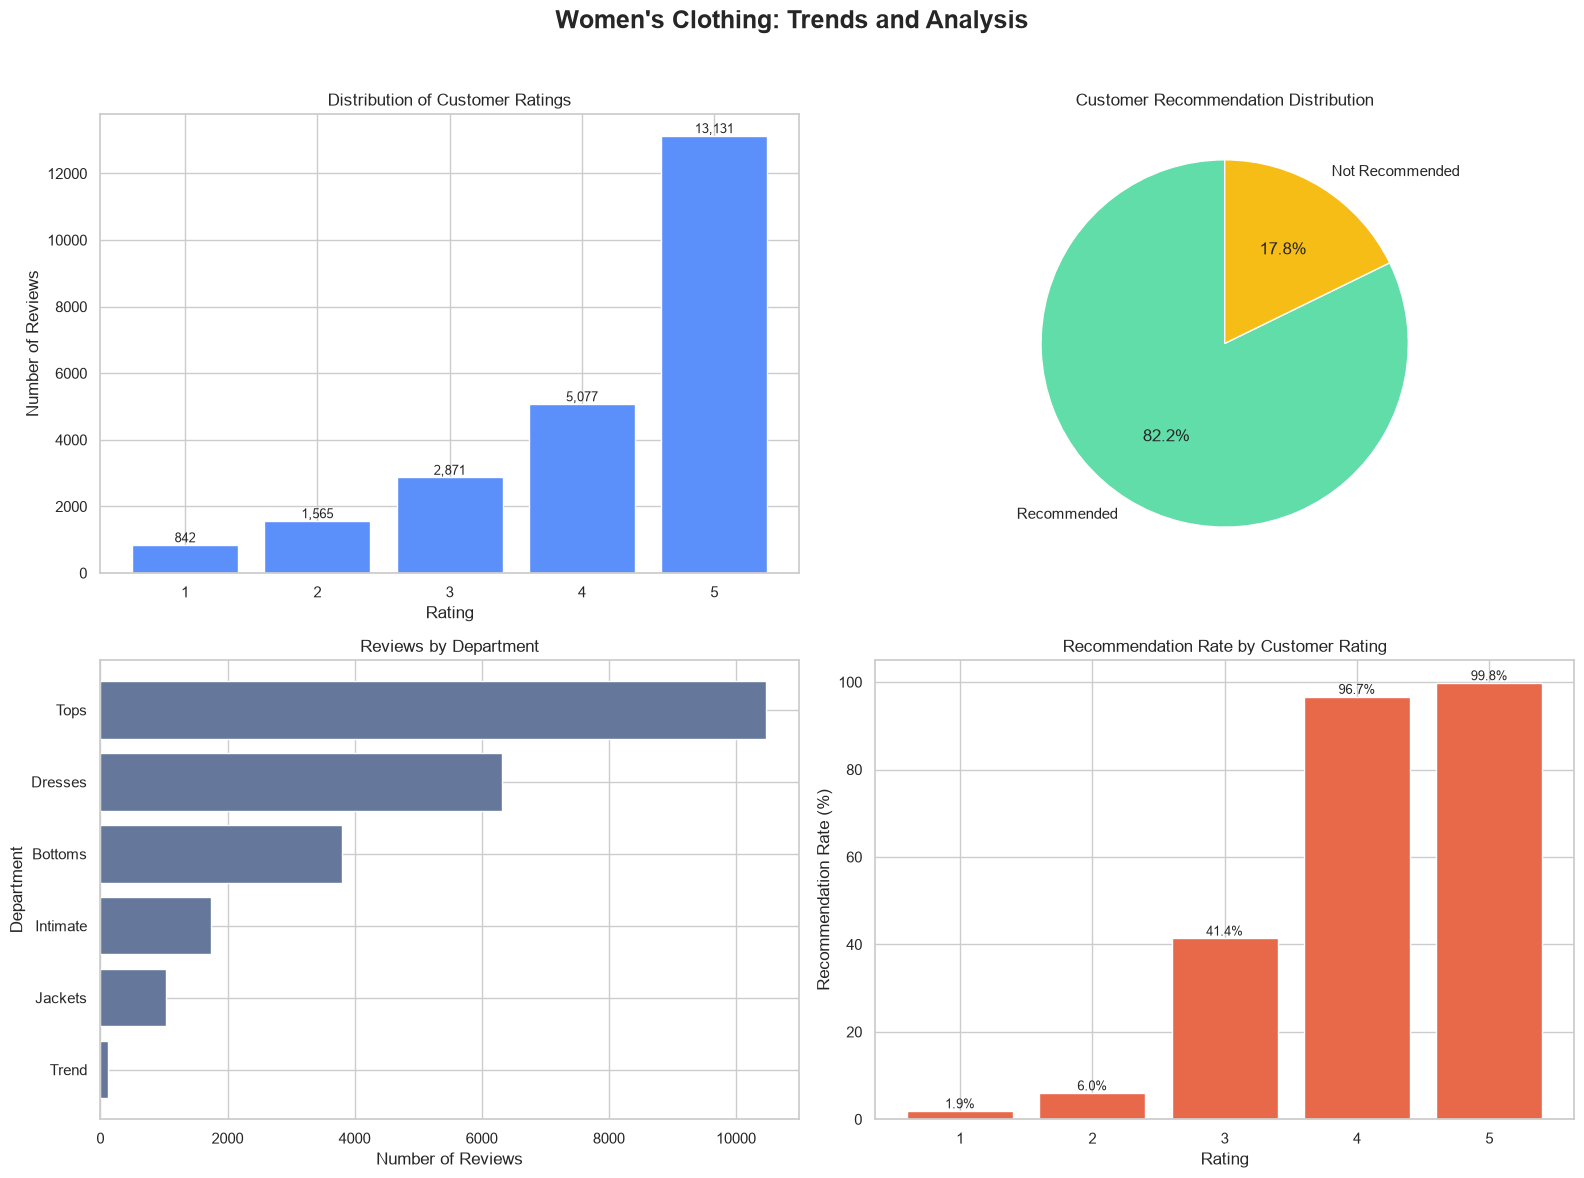

In [49]:
summary_dashboard = create_summary_dashboard(
    df_clean,
    department_trends,
    class_trends,
    rating_recommendation_summary
)

plt.show()

In [50]:
summary_dashboard.savefig(
    "womens_clothing_summary_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

print("Dashboard saved successfully.")

Dashboard saved successfully.


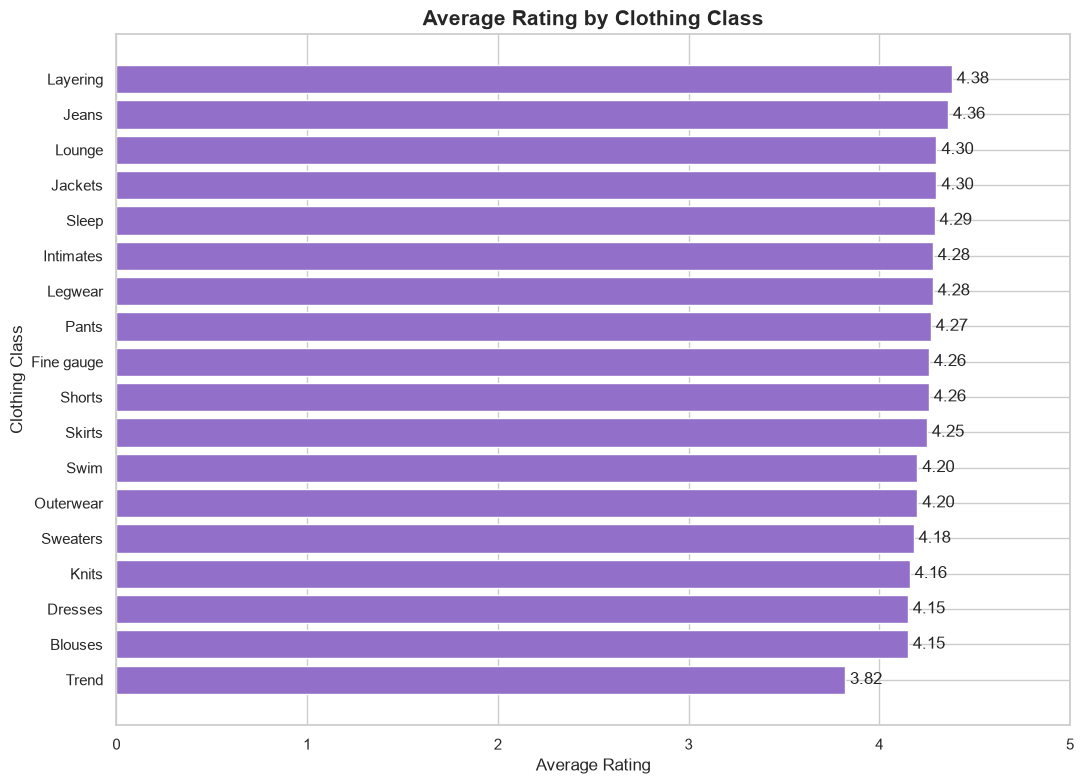

In [51]:
def plot_class_rating_trends(class_table):

    plot_data = (
        class_table[
            class_table["Eligible_for_Ranking"]
        ]
        .sort_values(
            "Average_Rating",
            ascending=True
        )
    )

    plt.figure(figsize=(11, 8))

    plt.barh(
        plot_data["Class Name"],
        plot_data["Average_Rating"],
        color="#9270CA"
    )

    plt.title(
        "Average Rating by Clothing Class",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Average Rating")
    plt.ylabel("Clothing Class")
    plt.xlim(0, 5)

    for index, value in enumerate(
        plot_data["Average_Rating"]
    ):
        plt.text(
            value,
            index,
            f" {value:.2f}",
            va="center"
        )

    plt.tight_layout()
    plt.show()

plot_class_rating_trends(class_trends)

In [52]:
def generate_rating_recommendation_summary(data):

    summary = (
        data
        .groupby("Rating")
        .agg(
            Review_Count=("Recommended IND", "count"),
            Recommended_Count=("Recommended IND", "sum"),
            Recommendation_Rate=(
                "Recommended IND",
                "mean"
            ),
            Average_Positive_Feedback=(
                "Positive Feedback Count",
                "mean"
            )
        )
        .reset_index()
    )

    summary["Recommendation_Rate"] = (
        summary["Recommendation_Rate"] * 100
    )

    summary[
        [
            "Recommendation_Rate",
            "Average_Positive_Feedback"
        ]
    ] = summary[
        [
            "Recommendation_Rate",
            "Average_Positive_Feedback"
        ]
    ].round(2)

    return summary

In [53]:
def generate_complete_report(data):

    report_numerical_columns = [
        "Age",
        "Rating",
        "Positive Feedback Count"
    ]

    numerical_summary_result = (
        generate_numerical_summary(
            data,
            report_numerical_columns
        )
    )

    numerical_insight_result = (
        generate_numerical_insights(
            numerical_summary_result
        )
    )

    domain_insight_result = (
        generate_domain_insights(
            numerical_summary_result
        )
    )

    categorical_data = data.copy()

    categorical_data["Recommendation Status"] = (
        categorical_data["Recommended IND"]
        .map({
            1: "Recommended",
            0: "Not Recommended"
        })
        .fillna("Unknown")
    )

    report_categorical_columns = [
        "Division Name",
        "Department Name",
        "Class Name",
        "Recommendation Status"
    ]

    (
        categorical_summary_result,
        categorical_frequency_result
    ) = generate_categorical_summary(
        categorical_data,
        report_categorical_columns
    )

    categorical_insight_result = (
        generate_categorical_insights(
            categorical_summary_result
        )
    )

    recommendation_insight_result = (
        generate_recommendation_insight(
            categorical_frequency_result
        )
    )

    text_summary_result = generate_text_summary(
        data,
        "Review Text"
    )

    overall_word_result = extract_common_terms(
        data["Review Text"],
        top_n=15,
        ngram_range=(1, 1)
    )

    overall_phrase_result = extract_common_terms(
        data["Review Text"],
        top_n=15,
        ngram_range=(2, 2)
    )

    high_reviews = data.loc[
        data["Rating"] >= 4,
        "Review Text"
    ]

    neutral_reviews = data.loc[
        data["Rating"] == 3,
        "Review Text"
    ]

    low_reviews = data.loc[
        data["Rating"] <= 2,
        "Review Text"
    ]

    high_term_result = extract_common_terms(
        high_reviews,
        top_n=15,
        ngram_range=(1, 1)
    )

    neutral_term_result = extract_common_terms(
        neutral_reviews,
        top_n=15,
        ngram_range=(1, 1)
    )

    low_term_result = extract_common_terms(
        low_reviews,
        top_n=15,
        ngram_range=(1, 1)
    )

    length_summary_result = pd.DataFrame({
        "Rating Segment": [
            "High Rating (4–5)",
            "Neutral Rating (3)",
            "Low Rating (1–2)"
        ],
        "Average Word Count": [
            calculate_average_review_length(
                high_reviews
            ),
            calculate_average_review_length(
                neutral_reviews
            ),
            calculate_average_review_length(
                low_reviews
            )
        ]
    })

    nlp_insight_result = generate_nlp_insights(
        text_summary_result,
        overall_word_result,
        high_term_result,
        low_term_result,
        length_summary_result
    )

    department_trend_result = (
        generate_group_trend_summary(
            data,
            "Department Name",
            minimum_reviews=50
        )
    )

    class_trend_result = (
        generate_group_trend_summary(
            data,
            "Class Name",
            minimum_reviews=50
        )
    )

    department_insight_result = (
        generate_group_trend_insights(
            department_trend_result,
            "Department Name"
        )
    )

    class_insight_result = (
        generate_group_trend_insights(
            class_trend_result,
            "Class Name"
        )
    )

    rating_recommendation_result = (
        generate_rating_recommendation_summary(
            data
        )
    )

    rating_recommendation_insight_result = (
        generate_rating_recommendation_insight(
            rating_recommendation_result
        )
    )

    report_lines = []

    report_lines.extend([
        "=" * 78,
        "WOMEN'S CLOTHING: TRENDS AND ANALYSIS IN THE FASHION INDUSTRY",
        "AUTOMATED STATISTICAL AND NLP SUMMARY REPORT",
        "=" * 78,
        "",
        "DATASET OVERVIEW",
        "-" * 78,
        f"Total records analysed: {len(data):,}",
        f"Total analytical columns: {data.shape[1]}",
        ""
    ])

    report_lines.extend([
        "1. NUMERICAL STATISTICAL INSIGHTS",
        "-" * 78
    ])

    for _, row in numerical_insight_result.iterrows():
        report_lines.append(
            f"\n{row['Column']}:\n{row['Insight']}"
        )

    report_lines.extend([
        "",
        "2. FASHION-DOMAIN INTERPRETATION",
        "-" * 78
    ])

    for insight in domain_insight_result:
        report_lines.append(f"\n• {insight}")

    report_lines.extend([
        "",
        "",
        "3. CATEGORICAL DISTRIBUTION INSIGHTS",
        "-" * 78
    ])

    for _, row in categorical_insight_result.iterrows():
        report_lines.append(
            f"\n{row['Column']}:\n{row['Insight']}"
        )

    report_lines.append(
        f"\nRecommendation Trend:\n"
        f"{recommendation_insight_result}"
    )

    report_lines.extend([
        "",
        "",
        "4. NLP REVIEW-TEXT INSIGHTS",
        "-" * 78
    ])

    for insight in nlp_insight_result:
        report_lines.append(f"\n• {insight}")

    report_lines.extend([
        "",
        "",
        "5. DEPARTMENT TRENDS",
        "-" * 78
    ])

    for insight in department_insight_result:
        report_lines.append(f"\n• {insight}")

    report_lines.extend([
        "",
        "",
        "6. CLOTHING-CLASS TRENDS",
        "-" * 78
    ])

    for insight in class_insight_result:
        report_lines.append(f"\n• {insight}")

    report_lines.extend([
        "",
        "",
        "7. RATING AND RECOMMENDATION RELATIONSHIP",
        "-" * 78,
        f"\n{rating_recommendation_insight_result}"
    ])

    rating_row = numerical_summary_result.set_index(
        "Column"
    ).loc["Rating"]

    recommendation_table = (
        categorical_frequency_result[
            "Recommendation Status"
        ].set_index("Category")
    )

    recommended_percentage = (
        recommendation_table.loc[
            "Recommended",
            "Percentage"
        ]
    )

    most_reviewed_department = (
        department_trend_result.loc[
            department_trend_result[
                "Review_Count"
            ].idxmax(),
            "Department Name"
        ]
    )

    report_lines.extend([
        "",
        "",
        "8. AUTOMATED CONCLUSION",
        "-" * 78,
        (
            f"\nThe dataset shows an overall average rating of "
            f"{rating_row['Mean']:.2f} out of 5. "
            f"Approximately {recommended_percentage:.2f}% of reviews "
            f"recommend the products, indicating generally positive "
            f"customer satisfaction. '{most_reviewed_department}' is "
            f"the most actively reviewed department. NLP analysis "
            f"reveals the product attributes and experiences most "
            f"frequently discussed by satisfied and dissatisfied "
            f"customers."
        ),
        "",
        "=" * 78,
        "END OF AUTOMATED REPORT",
        "=" * 78
    ])

    complete_report_text = "\n".join(report_lines)

    return {
        "report_text": complete_report_text,
        "numerical_summary": numerical_summary_result,
        "categorical_summary": categorical_summary_result,
        "categorical_frequencies": categorical_frequency_result,
        "text_summary": text_summary_result,
        "top_words": overall_word_result,
        "top_phrases": overall_phrase_result,
        "high_rating_terms": high_term_result,
        "neutral_rating_terms": neutral_term_result,
        "low_rating_terms": low_term_result,
        "review_length_summary": length_summary_result,
        "department_trends": department_trend_result,
        "class_trends": class_trend_result,
        "rating_recommendation": rating_recommendation_result
    }

In [54]:
report_results = generate_complete_report(
    df_clean
)

complete_report = report_results["report_text"]

print(complete_report)

WOMEN'S CLOTHING: TRENDS AND ANALYSIS IN THE FASHION INDUSTRY
AUTOMATED STATISTICAL AND NLP SUMMARY REPORT

DATASET OVERVIEW
------------------------------------------------------------------------------
Total records analysed: 23,486
Total analytical columns: 10

1. NUMERICAL STATISTICAL INSIGHTS
------------------------------------------------------------------------------

Age:
Age has an average value of 43.20, a median of 41.00, and a mode of 39. Values range from 18.00 to 99.00. The middle 50% of observations lie between 34.00 and 52.00. The mean is greater than the median, suggesting that some higher values are lifting the average. The distribution is moderately skewed to the right. It shows moderate relative variability (coefficient of variation: 28.4%). Its kurtosis indicates a tail pattern reasonably close to a normal distribution. No missing values were found in this column.

Rating:
Rating has an average value of 4.20, a median of 5.00, and a mode of 5. Values range from 1.

In [55]:
display(report_results["numerical_summary"])
display(report_results["categorical_summary"])
display(report_results["top_words"])
display(report_results["department_trends"])
display(report_results["class_trends"])

,Column,Count,Missing,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Q1,Q3,Maximum,Range,IQR,Skewness,Kurtosis
0,Age,23486,0,43.199,41.0,39,150.787,12.280,18,34.0,52.0,99,81,18.0,0.526,-0.112
1,Rating,23486,0,4.196,5.0,5,1.232,1.110,1,4.0,5.0,5,4,1.0,-1.314,0.804
2,Positive Feedback Count,23486,0,2.536,1.0,0,32.515,5.702,0,0.0,3.0,122,122,3.0,6.473,71.693


,Column,Total Records,Unique Categories,Most Frequent Category,Top Category Frequency,Top Category Percentage,Least Frequent Category,Least Category Frequency
0,Division Name,23486,4,General,13850,58.97,Unknown,14
1,Department Name,23486,7,Tops,10468,44.57,Unknown,14
2,Class Name,23486,21,Dresses,6319,26.91,Chemises,1
3,Recommendation Status,23486,2,Recommended,19314,82.24,Not Recommended,4172


,Term,Frequency
0,dress,10567
1,love,8951
2,size,8772
3,fit,7325
4,like,7149
5,wear,6439
6,great,6117
7,just,5608
8,fabric,4798
9,small,4729


,Department Name,Review_Count,Average_Rating,Median_Rating,Recommendation_Rate,Average_Positive_Feedback,Total_Positive_Feedback,Eligible_for_Ranking
0,Bottoms,3799,4.29,5.0,85.13,2.12,8043,True
1,Dresses,6319,4.15,5.0,80.82,3.09,19510,True
2,Intimate,1735,4.28,5.0,85.01,1.89,3275,True
3,Jackets,1032,4.26,5.0,83.62,2.83,2916,True
4,Tops,10468,4.17,5.0,81.52,2.43,25407,True
5,Trend,119,3.82,4.0,73.95,3.37,401,True


,Class Name,Review_Count,Average_Rating,Median_Rating,Recommendation_Rate,Average_Positive_Feedback,Total_Positive_Feedback,Eligible_for_Ranking
0,Blouses,3097,4.15,5.0,81.01,2.73,8440,True
1,Casual bottoms,2,4.50,4.5,100.0,0.00,0,False
2,Chemises,1,4.00,4.0,100.0,0.00,0,False
3,Dresses,6319,4.15,5.0,80.82,3.09,19510,True
4,Fine gauge,1100,4.26,5.0,83.73,2.01,2215,True
5,Intimates,154,4.28,5.0,85.71,0.78,120,True
6,Jackets,704,4.30,5.0,84.52,2.83,1990,True
7,Jeans,1147,4.36,5.0,88.14,1.76,2018,True
8,Knits,4843,4.16,5.0,81.77,2.39,11598,True
9,Layering,146,4.38,5.0,88.36,1.32,192,True


In [56]:
with open(
    "womens_clothing_automated_report.txt",
    "w",
    encoding="utf-8"
) as report_file:
    report_file.write(complete_report)

report_results["numerical_summary"].to_csv(
    "numerical_summary.csv",
    index=False
)

report_results["categorical_summary"].to_csv(
    "categorical_summary.csv",
    index=False
)

report_results["department_trends"].to_csv(
    "department_trends.csv",
    index=False
)

report_results["class_trends"].to_csv(
    "class_trends.csv",
    index=False
)

report_results["top_words"].to_csv(
    "top_review_words.csv",
    index=False
)

report_results["rating_recommendation"].to_csv(
    "rating_recommendation_summary.csv",
    index=False
)

print("Report and supporting tables exported successfully.")

Report and supporting tables exported successfully.


In [57]:
def validate_project_results(results, expected_records):

    validation_checks = []

    report_text = results.get("report_text", "")

    validation_checks.append({
        "Validation Check": "Human-readable report generated",
        "Status": (
            "PASS" if len(report_text.strip()) > 500
            else "FAIL"
        )
    })

    numerical_table = results.get(
        "numerical_summary",
        pd.DataFrame()
    )

    required_statistics = {
        "Mean",
        "Median",
        "Variance"
    }

    validation_checks.append({
        "Validation Check": "Mean, median and variance available",
        "Status": (
            "PASS"
            if required_statistics.issubset(
                numerical_table.columns
            )
            else "FAIL"
        )
    })

    correct_count = (
        not numerical_table.empty
        and numerical_table["Count"].max()
        == expected_records
    )

    validation_checks.append({
        "Validation Check": "All dataset records analysed",
        "Status": "PASS" if correct_count else "CHECK"
    })

    categorical_table = results.get(
        "categorical_summary",
        pd.DataFrame()
    )

    validation_checks.append({
        "Validation Check": "Categorical summary generated",
        "Status": (
            "PASS"
            if not categorical_table.empty
            else "FAIL"
        )
    })

    top_words_table = results.get(
        "top_words",
        pd.DataFrame()
    )

    validation_checks.append({
        "Validation Check": "NLP terms extracted",
        "Status": (
            "PASS"
            if not top_words_table.empty
            else "FAIL"
        )
    })

    department_table = results.get(
        "department_trends",
        pd.DataFrame()
    )

    validation_checks.append({
        "Validation Check": "Department trends generated",
        "Status": (
            "PASS"
            if not department_table.empty
            else "FAIL"
        )
    })

    class_table = results.get(
        "class_trends",
        pd.DataFrame()
    )

    validation_checks.append({
        "Validation Check": "Clothing-class trends generated",
        "Status": (
            "PASS"
            if not class_table.empty
            else "FAIL"
        )
    })

    return pd.DataFrame(validation_checks)

final_validation = validate_project_results(
    report_results,
    expected_records=len(df_clean)
)

display(final_validation)

,Validation Check,Status
0,Human-readable report generated,PASS
1,"Mean, median and variance available",PASS
2,All dataset records analysed,PASS
3,Categorical summary generated,PASS
4,NLP terms extracted,PASS
5,Department trends generated,PASS
6,Clothing-class trends generated,PASS


In [58]:
expected_files = [
    "womens_clothing_automated_report.txt",
    "numerical_summary.csv",
    "categorical_summary.csv",
    "department_trends.csv",
    "class_trends.csv",
    "top_review_words.csv",
    "rating_recommendation_summary.csv",
    "womens_clothing_summary_dashboard.png"
]

file_verification = []

for file_name in expected_files:
    file_path = Path(file_name)

    file_verification.append({
        "File": file_name,
        "Created": file_path.exists(),
        "File Size (KB)": (
            round(file_path.stat().st_size / 1024, 2)
            if file_path.exists()
            else 0
        )
    })

file_verification_df = pd.DataFrame(
    file_verification
)

display(file_verification_df)

,File,Created,File Size (KB)
0,womens_clothing_automated_report.txt,True,6.54
1,numerical_summary.csv,True,0.35
2,categorical_summary.csv,True,0.38
3,department_trends.csv,True,0.40
4,class_trends.csv,True,0.97
5,top_review_words.csv,True,0.19
6,rating_recommendation_summary.csv,True,0.19
7,womens_clothing_summary_dashboard.png,True,353.74
